سوال 1

براساس تحلیل مرحله قبل:

کدام ستون‌ها بیشترین ارتباط را با target داشتند؟

فهرست آن‌ها را استخراج کنید.

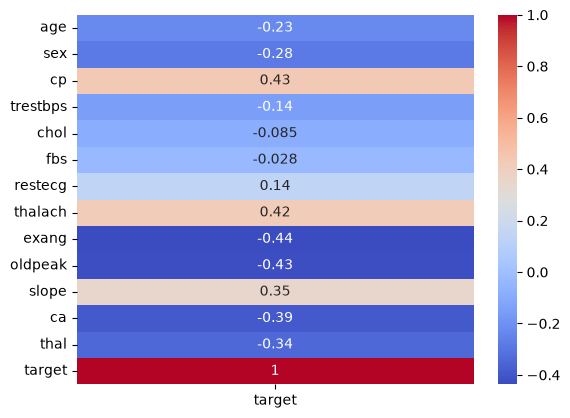

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/heart.csv")

corr = df.corr()
corr['target'].sort_values(ascending=False)
sns.heatmap(corr[['target']],
            annot=True,
            cmap="coolwarm",

            )
plt.show()

 برای بدست اوردن ارتباط بهتر بین ستون ها و تارگت میتوانیم از هیت مپ استفاده کنیم
 بازه اعدادی که نزدیک تر به 0/5 + تا 1 و -0/5 تا 0 هستند ارتباط بالایی دارند با تارگت
 مثل exang و oldpeakو cpوthalach
 اعداد منفی ارتباط عکس دارند ولی باز هم داده های مفیدی هستند
 از داده های منفی قدر مطلق میگیریم

سوال 2

یک جدول تهیه کنید:

Feature
Business Importance
Data Importance

In [30]:
df = list(df.columns)
df

['age',
 'sex',
 'cp',
 'trestbps',
 'chol',
 'fbs',
 'restecg',
 'thalach',
 'exang',
 'oldpeak',
 'slope',
 'ca',
 'thal',
 'target']

Feature:اسم ویژگی ها که همان ستون ها است
و تا قبل اینکه داده ها را تمیز تر و مرتب کنیم همه ی ستون های دیتا ست ویژگی های مهم هستند

In [31]:
dict_target = {
    'age': 'high',
    'sex': 'low',
    'cp': 'very high',
    'trestbps': 'high',
    'chol': 'high',
    'fbs': 'low',
    'restecg': 'high',
    'thalach': 'high',
    'exang': 'high',
    'oldpeak': 'very high',
    'slope': 'very low',
    'ca': 'high',
    'thal': 'very low',

}
dict_target

{'age': 'high',
 'sex': 'low',
 'cp': 'very high',
 'trestbps': 'high',
 'chol': 'high',
 'fbs': 'low',
 'restecg': 'high',
 'thalach': 'high',
 'exang': 'high',
 'oldpeak': 'very high',
 'slope': 'very low',
 'ca': 'high',
 'thal': 'very low'}

Business Importance:ویژگی های مهم از نظر کسب وکار
حتی اگر رشته ی شما با دیتا ست مرتبط نباشند میتوان با یک سرچ ساده راجب دادنه ها میزان اهمیت ان ها از نظر کسب و کار را فهمید

In [32]:
dict_target = {
    'age': 'low= -0.23',
    'sex': 'low= -0.28',
    'cp': 'high= 0.43',
    'trestbps': 'very low= -0.14',
    'chol': 'very low= -0.085',
    'fbs': 'very low= -0.028',
    'restecg': 'very low= 0.14',
    'thalach': 'high= 0.42',
    'exang': 'high= -0.44',
    'oldpeak': 'high= -0.43',
    'slope': 'high= 0.35',
    'ca': 'high= -0.39',
    'thal': 'high= -0.34',

}
dict_target

{'age': 'low= -0.23',
 'sex': 'low= -0.28',
 'cp': 'high= 0.43',
 'trestbps': 'very low= -0.14',
 'chol': 'very low= -0.085',
 'fbs': 'very low= -0.028',
 'restecg': 'very low= 0.14',
 'thalach': 'high= 0.42',
 'exang': 'high= -0.44',
 'oldpeak': 'high= -0.43',
 'slope': 'high= 0.35',
 'ca': 'high= -0.39',
 'thal': 'high= -0.34'}

Data Importance:ویژگی های مهم از بررسی دیتا ست
برای اینکه از نظر یادگیری مدل بفهمیم این داده پقد اهمیت دارد باید باز رجوع کنیم به جدول همبستگی
داده ای که ارتباط مستقیم یا غیر مسقیمی با تارگت دارند برای اموزش مدل بهتر است

سوال 3

حداقل سه ویژگی را انتخاب کنید که احتمال می‌دهید برای مدل‌سازی مفید نباشند.

دلایل خود را بنویسید.

In [33]:

dict_target = {
    'age': 'low= -0.23',
    'sex': 'low= -0.28',
    'cp': 'high= 0.43',
    'trestbps': 'very low= -0.14',
    'chol': 'very low= -0.085',
    'fbs': 'very low= -0.028',
    'restecg': 'very low= 0.14',
    'thalach': 'high= 0.42',
    'exang': 'high= -0.44',
    'oldpeak': 'high= -0.43',
    'slope': 'high= 0.35',
    'ca': 'high= -0.39',
    'thal': 'high= -0.34',

}
dict_target

{'age': 'low= -0.23',
 'sex': 'low= -0.28',
 'cp': 'high= 0.43',
 'trestbps': 'very low= -0.14',
 'chol': 'very low= -0.085',
 'fbs': 'very low= -0.028',
 'restecg': 'very low= 0.14',
 'thalach': 'high= 0.42',
 'exang': 'high= -0.44',
 'oldpeak': 'high= -0.43',
 'slope': 'high= 0.35',
 'ca': 'high= -0.39',
 'thal': 'high= -0.34'}

 برای اینکه بفهمیم چه ویژگی هایی برای اموزش مدل ما بهترین است از جدول همبستگی ویژگی هایی را که در تارگت تاثیر دارند را انتخاب میکنیم
  با توجه به توضیحات قبلی cholو fbsو trestbps restecg کمترین تاثیر روی اموزش مدل دارند

سوال 4

یک نسخه جدید از دیتاست بسازید که فقط شامل ویژگی‌های منتخب شما باشد.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/heart.csv")
selected_df = df[
    ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']]
selected_df

,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,1,115,1,1.2,1,1,3,0


برای حذف کردن ستون ها باید دلیل منطقی وجود داشته باشد و نمیتوان همینطوری حذف کرد
اگر ستونی از نظر کسب و کار مهم است ولی در اموزش مدل زیاد مهم نیست باز نمیتوان ان ستون را حذف کرد
بعضی از ستون ها چه از نظر کسب و کار و چه از نظر یادگیری مدل کم اهمیت تر هستند مثل ستون های fbs و slope و thal
ولی فقط ستون fbsرا میتوان حذف کرد برای دیتاست جدید چونکه دو ستون دیگر از نظر مدل سازی اهمیت دارند

سوال 5

تعداد ویژگی‌ها قبل و بعد از Selection را مقایسه کنید.

In [35]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


دیتا ست اولیه دارای 14 ستون است که ستون هایی دارد که از نظر اموزش مدل یا از دید کسب و کار اهمیت چندانی ندارند و میتوان ان ها را حذف کرد
حجم ان 33 کیلو بایت است

In [36]:
selected_df.info()
selected_df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   restecg   303 non-null    int64  
 6   thalach   303 non-null    int64  
 7   exang     303 non-null    int64  
 8   oldpeak   303 non-null    float64
 9   slope     303 non-null    int64  
 10  ca        303 non-null    int64  
 11  thal      303 non-null    int64  
 12  target    303 non-null    int64  
dtypes: float64(1), int64(12)
memory usage: 30.9 KB


,age,sex,cp,trestbps,chol,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


دیتا ست دومی که خودمون با ویژگی های ارزشمند تشکیل دادیم دارای 11 ستون است از اطلاعات مهم تر
حجم ان از 33کیلوبایت کمتر شده تا 26کیلو بایت

سوال 6

تمام مقادیر Null را مجدداً بررسی کنید.

In [37]:
selected_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

در اینجا با توجه به اینکه هیچ مقدار ثبت نشده ای وجود ندارد
یعنی داده ها کامل وارد شده اند

سوال 7

برای هر ستون مشخص کنید:

تعداد Null
درصد Null

In [38]:
selected_df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

تعداد مقادیر خالی ما صفر است
پس درصد ان نیز صفر میشود

In [39]:
selected_df.isnull().sum() * 100

age         0
sex         0
cp          0
trestbps    0
chol        0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

سوال 8

اگر داده گمشده وجود دارد:

سه روش مختلف برای پر کردن آن پیشنهاد دهید.

In [40]:
df.isna().sum() * 100

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

داده گمشده نداریم ولی روش هایی که برای پرکردن داده گمشده هستند:
1.حذف یک رکورد
2.استفاده از مدل های پیش بینی
3.جایگذاری با میانگین
4.مقدار ثابت(ضعیف ترین روش)

سوال 9

یکی از روش‌ها را انتخاب کرده و پیاده‌سازی کنید.

داده گمشده نداریم ولی با توجه به روش های گفته شده میتوان روش هایی را بررسی کرد
در بعضی رکورد ها میتوان از رکورد های قبلی یا بعدی استفاده کرد برای میانگین گرفتن
اگر در رکوردی داده های گمشده ی زیادی داشتیم میتوان در صورت لزوم و با توجه به اهمیت رکورد ان را حذف کرد

سوال 10

رکوردهای تکراری را شناسایی کنید.

In [41]:
df = pd.read_csv("data/heart.csv")
selected_df = df[
    ['age', 'sex', 'cp', 'trestbps', 'chol', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']]
print(selected_df.duplicated().sum())
print(selected_df[df.duplicated()])

1
     age  sex  cp  trestbps  chol  restecg  thalach  exang  oldpeak  slope  \
164   38    1   2       138   175        1      173      0      0.0      2   

     ca  thal  target  
164   4     2       1  


در صورت ادغام دو دیتا بیس یا ثبت شدن دوباره ی رکوردی میتوان داده ی تکراری داشت
فقط یک داده ی تکراری داریم

سوال 11

نسخه‌ای از داده بدون رکوردهای تکراری ایجاد کنید.

In [42]:
selected_df = selected_df.drop_duplicates()

ابتدا یک نسخه ی بدون داده تکراری را در دیتا ست جدیدی که ساختیم میریزیم

In [43]:
print(selected_df.duplicated().sum())

0


سپس برای اطمینان دوباره داده های تکراری دیتا ست را میشماریم
اگر مراحل را درست رفته باشیم دیگر داده و رکورد تکراری نداری

سوال 12

با استفاده از Boxplot و IQR:

Outlier های هر ویژگی عددی را پیدا کنید.



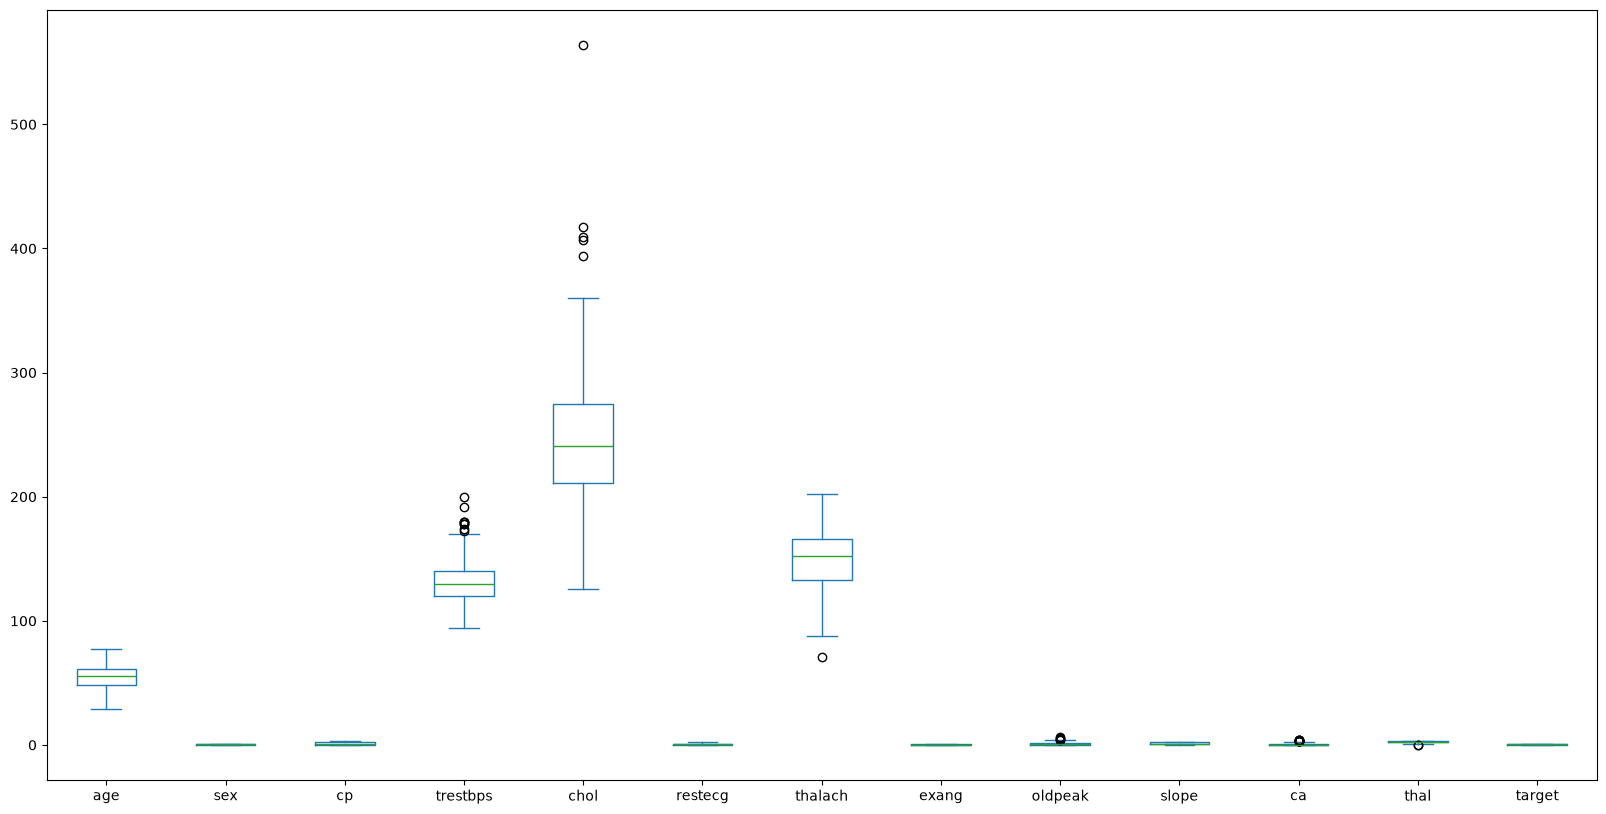

In [44]:
selected_df.plot.box(figsize=(20, 10))
plt.show()

ابتدا با استفاده از باکس پلات داده های پرت را بدست می اوریم
که با توجه به نمودار در ستون thalachداده های پرت قابل توجهی داریم

In [45]:
for column in ['age', 'cp', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']:
    Q1 = selected_df[column].quantile(0.25)
    Q3 = selected_df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = selected_df[(selected_df[column] < Q1 - 1.5 * IQR) | (selected_df[column] > Q3 + 1.5 * IQR)]
    print(f"{column}",outliers[column].values)

age []
cp []
restecg []
thalach [71]
exang []
oldpeak [4.2 6.2 5.6 4.2 4.4]
slope []
ca [3 4 3 3 4 4 3 3 3 3 3 3 3 3 3 3 3 3 3 4 3 3 3 3]
thal [0 0]
target []


سپس با استفاده از چارک ها داده های پرت ستون ها را دقیق تر بدست می اوریم

سوال 13

جدولی ایجاد کنید:

| Feature | Number of Outliers |

In [46]:
for column in ['age', 'cp', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']:
    Q1 = selected_df[column].quantile(0.25)
    Q3 = selected_df[column].quantile(0.75)
    IQR = Q3 - Q1
    outliers = selected_df[(selected_df[column] < Q1 - 1.5 * IQR) | (selected_df[column] > Q3 + 1.5 * IQR)]
    print(f"{column}: {len(outliers)} number outlier")

age: 0 number outlier
cp: 0 number outlier
restecg: 0 number outlier
thalach: 1 number outlier
exang: 0 number outlier
oldpeak: 5 number outlier
slope: 0 number outlier
ca: 24 number outlier
thal: 2 number outlier
target: 0 number outlier


با توجه به خروجی خیلی از ستون هامون داده ی پرت ندارند

سوال 14

برای Outlier ها سه استراتژی مختلف پیشنهاد دهید.

برای داده های پرت ابتدا باید بررسی کنیم که ایا خطای ورودی داریم یا نه
که میتوانیم مقدار را ویرایش کنیم و مقدار درست را جایگذاری کنیم(در صورت دسترسی) یا اینکه حذف کنیم
یا ممکن است مقدار واقعی باشد ولی کمیاب مثل درامد خیلی زیاد بین درامدهای معمولی
پس حذف کردن زیاد منطقی نیست
در ستون fbsمقادیر به صورت دودویی چاپ شدن پس لزوما داده ی پرت نیستند پس مقادیر پرت وجود ندارند
در ستون thalach مقدار 71 ضربانی غیر طبیعی و بیمار گونه است ولی امکان وجود ان نیز هست
در ستونoldpeakداده هامون باید بین 0 تا بیشتر از 4 میلی متر باشند و این درسته که بیشتر داده هامون کمتر از 2 هستند ولی داده ی پرت نداریم صرفا میزان افت قطعه اس تی بالاتر از حدنرمال است و خطرناک است از نظر پزشکی
در ستون caتعداد عروق کرونری اصلی درگیر باید از 0 تا 4 باشد و از نظر پزشکی داده ی پرتی وجود ندارد
در ستون thalمقادیر ما باید دسته ای باشند از 1تا3 یا از 0تا 2 یعنی دسته ی 3تایی باید باشند و در اینجا هم عدد 3 داریم و هم 0 که امکان پذیر نیست و میتوان گفت دو داده ای که مقدار ان 0 است داده ی پرت هستند که شاید به دلیل خالی نگذاشتن جای ان ها زا مقدار ثابت 0 استفاده شده

پس از بین داده های پرتی که از پلات باکس بدست اوردیم فقط ستون thalواقعا داده ی پرت دارد

سوال 15

یک استراتژی را انتخاب و پیاده‌سازی کنید.

In [47]:
selected_df['thal'].value_counts()

thal
2    165
3    117
1     18
0      2
Name: count, dtype: int64

با توجه به تحلیل سوال قبل در ستون thalدو مقدار پرت داریم که حدس میزنیم صرفا برای خالی نبودن دیتا در ان رکورد قرار داده شده
و از انجایی که فقط دو دیتای پرت داریم پس با حذف ان ها مشکلی برای دیتاست به وجود نمی اید

In [48]:
selected_df=selected_df[selected_df['thal']!=0]
selected_df['thal'].value_counts()

thal
2    165
3    117
1     18
Name: count, dtype: int64

در نهایت چک میکنیم تا مطمعن شویم داده های پرت حذف شده اند

## سوال 16

سن را به سه گروه تقسیم کنید:

* Young
* Middle Age
* Senior

ستون جدید:

```python
age_group
```

---

In [49]:
age_bins= [0,34,59,120]
age_labels= ["Young","Middle_Age","Senior"] 
selected_df["age_group"] = pd.cut(selected_df["age"] , bins=age_bins, labels=age_labels ,right=True)
print(selected_df[["age","age_group"]].head(20))

    age   age_group
0    63      Senior
1    37  Middle_Age
2    41  Middle_Age
3    56  Middle_Age
4    57  Middle_Age
5    57  Middle_Age
6    56  Middle_Age
7    44  Middle_Age
8    52  Middle_Age
9    57  Middle_Age
10   54  Middle_Age
11   48  Middle_Age
12   49  Middle_Age
13   64      Senior
14   58  Middle_Age
15   50  Middle_Age
16   58  Middle_Age
17   66      Senior
18   43  Middle_Age
19   69      Senior


## سوال 17

برای chol سطح ریسک ایجاد کنید:

* Low
* Normal
* High

---

In [50]:
chol_bins = [0,199,239,600]
labels= ["Low","Normal","High"]
selected_df["chol_level"]= pd.cut(selected_df["chol"], bins=chol_bins, labels=labels, right=True)
print(selected_df[["chol","chol_level"]].head())

   chol chol_level
0   233     Normal
1   250       High
2   204     Normal
3   236     Normal
4   354       High


## سوال 18

برای trestbps سطح فشار خون تعریف کنید.

---

In [51]:
trestbps_bins= [0,119,139,300]

selected_df["trestbps_level"]=pd.cut(selected_df["trestbps"], bins= trestbps_bins, labels= labels, right=True )
print(selected_df[["trestbps","trestbps_level"]].head())

   trestbps trestbps_level
0       145           High
1       130         Normal
2       130         Normal
3       120         Normal
4       120         Normal


## سوال 19

حداقل دو Feature جدید طراحی کنید.

دلایل کسب‌وکاری آن را توضیح دهید.

---

In [52]:
oldpeak_bins= [0,0.5,1.5,10]
ratio_bins= [0,2,4,10]
selected_df["oldpeak_level"]=pd.cut(selected_df["oldpeak"],bins= oldpeak_bins, labels=labels, right=True)
selected_df["chol_thalach_ratio"]= selected_df["chol"]/selected_df["thalach"]
selected_df["chol_thalach_ratio"]= pd.cut(selected_df["chol_thalach_ratio"], bins=ratio_bins, labels=labels)
print(selected_df[["oldpeak","oldpeak_level","chol_thalach_ratio"]].head())

   oldpeak oldpeak_level chol_thalach_ratio
0      2.3          High                Low
1      3.5          High                Low
2      1.4        Normal                Low
3      0.8        Normal                Low
4      0.6        Normal             Normal


## سوال 20

جدول زیر را تکمیل کنید:

| New Feature | Business Reason |

---

جنسیت رابطه مستقیم داره رو بیماری ولی این رابطه خطی نیست بخاطر همین به ۳ گروه تقسیم میکنیم تا بهتر بتونیم تحلیلش کنیم
برای اینکه راحت تر متوجه بشیم کلسترول و شیب اس تس نرمال هستند اونارو به ۳ دسته پایین نرمال و بالا تقسیم میکنیم تا راحت تر متوجه بشیم مشکل داره
فشار خون بسیار متغیر میتونه باشه نسبت به شرایط اندازه گیری بخاطر همین گروه بندی میکنیم تا حد امکان از خطاش و نوسان لحظه ای جلوگیری کنیم
نسبت کلسترول به حداکثر ضربان قلب برای این هستش که کسانی که کلسترول بالا دارند ولی حداکثر ضربان قلبشون در تست ورزش پایینه راحت تر پیدا کنیم چون این افراد در معرض خطر زیادی هستند

# بخش چهارم

# Data Integration

---

فرض کنید داده جدیدی از آزمایشگاه دریافت شده است.

فایل فرضی:

```python
lab_results.csv
```

---

 سوال 21

یک DataFrame آزمایشی بسازید.



In [59]:
import pandas as pd
import numpy as np


lab_df = pd.DataFrame({
    'patient_id': range (1, len(selected_df) +1),
    'blood_sugar': np.random.randint(70,150, len(selected_df)),
    'cholesterol_lab': np.random.randint(150,300, len(selected_df))
})

print(lab_df.head())


   patient_id  blood_sugar  cholesterol_lab
0           1          128              283
1           2          122              182
2           3           92              259
3           4           94              215
4           5           85              198


ادغام داده ها با ساخت یک دیتافریم آزمایشگاهی فرضی و وصل کردنش به دیتاست اصلی
وی این سوال
ما یک دیتافریم جدید ساختیم به اسم :
Lab_df
سه تا ستون توش گذاشتیم
Patient_id
برای  اینکه بعدا بتونیم به دیتاست اصلی وصلش کنیم

blood_sugar
قند خون _ با عداد تصادفی
Cholesterol_lab
کلسترول با عداد تصادفی
np.random.randint 
اطلاعات تصادفی توش ریختیم

خروجی
یک دیتافریم آزمایشگاهی با ۳۰۳ رکورد و ۳ ستون
 (patient_id, blood_sugar, cholesterol_lab) 
ساخته شد که برای ادغام با دیتاست اصلی آماده است.

 سوال 22

یک کلید مشترک تعریف کنید.



In [60]:
print('merge key:','patient')

merge key: patient


سوال 23

Merge را انجام دهید.



In [68]:
merged_df = pd.merge(selected_df, lab_df, on='patient_id', how='inner')
print(merged_df.head())

   age  sex  cp  trestbps  chol  restecg  thalach  exang  oldpeak  slope  ca  \
0   63    1   3       145   233        0      150      0      2.3      0   0   
1   37    1   2       130   250        1      187      0      3.5      0   0   
2   41    0   1       130   204        0      172      0      1.4      2   0   
3   56    1   1       120   236        1      178      0      0.8      2   0   
4   57    0   0       120   354        1      163      1      0.6      2   0   

   thal  patient_id  blood_sugar  cholesterol_lab  
0     1           1           79              279  
1     2           2          100              294  
2     2           3           89              168  
3     2           4          140              157  
4     2           5           80              170  


 سوال 24

انواع Merge زیر را مقایسه کنید:

* inner
* left
* right
* outer


 سوال 25

مشخص کنید برای این پروژه کدام نوع Merge مناسب‌تر است.



In [69]:
final_df =pd.merge(selected_df, lab_df, on ='patient_id', how='inner')
print('Suitable type:', 'inner')


Suitable type: inner


 بخش پنجم

 Data Formatting



 سوال 26

نوع داده تمامی ستون‌ها را بررسی کنید

In [79]:
print(merged_df.dtypes)
print(merged_df.info())

category
<class 'pandas.Series'>
RangeIndex: 303 entries, 0 to 302
Series name: sex
Non-Null Count  Dtype   
--------------  -----   
303 non-null    category
dtypes: category(1)
memory usage: 451.0 bytes
None


 سوال 27

ستون‌هایی که باید Category باشند را شناسایی کنید.



In [ ]:
categorical_cols = ['sex','cp','fbs','restecg','exang','slope','thal','target']

categorical


 سوال 28

Datatype مناسب را اعمال کنید.



In [85]:
for col in categorical_cols:
    df[col] = df[col].astype('category')
    print(merged_df.dtypes)

category
category
category
category
category
category
category
category


 سوال 29

حجم حافظه قبل و بعد از تغییر datatype را مقایسه کنید.



In [89]:
memory= df.memory_usage(deep=True).sum()

for col in categorical_cols:
    df[col] = df[col].astype('category')

New_memory= df.memory_usage(deep=True).sum()

print(memory)
print(New_memory)

17276
17276


 سوال 30

ستون‌های متنی را استانداردسازی کنید.

مثال:

```python
Male
male
MALE


In [96]:
text_col=df.select_dtypes(include=['object']).columns.tolist()
if text_col:
    for col in text_col:
        df[col] = df[col].str.lower() .str.strip()
        print('Standardization completed for :' , text_col)
else:
    print('No text columns found  the dataset')

No text columns found  the dataset
